# Item2Vec

This notebook explores an `Item2Vec` approach, inspired by the Word2Vec model, but applied to items (videos) instead of words. The core idea is to treat sequences of videos watched by users as "sentences," assuming that items watched closely in time are semantically related — just like words in a sentence.

We train a Word2Vec model on these sequences, so that items which frequently co-occur in user histories will have similar vector representations in the learned embedding space.

To make recommendations:
- For a given user, we compute the **mean embedding** of items they **liked** (`watch_ratio >= 2`, according to the paper).
- Optionally, we subtract the **mean embedding** of items they **disliked** (`watch_ratio <= 0.8`, best empirically) to form a more personalized query vector.
- We then retrieve the top-K most **cosine-similar items** to this vector — excluding items the user has already seen.

This is a **hybrid approach** that blends:
- **Content-based filtering** (item embe),
- with a **sequence-aware model** (embedding items based on how they appear in viewing sequences).

The method is simple and scalable, making it a strong baseline, although performance depends heavily on the quality of co-occurrence signals and user behavior patterns.


In [23]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from gensim.models.word2vec import Word2Vec

from src.metrics import RecoMetrics
from src.utils import *

---

# Data reading and preprocessing

We first read all the data

In [4]:
COLS = ["user_id", "video_id", "timestamp", "watch_ratio"]

X_train = read_matrix("big", "big_matrix")[COLS]
X_val = read_matrix("small", "small_matrix")[COLS]

--- Reading big matrix ---
Loading...
Cleaning...
0.08% of the data has been filtered out
--- Readed in 22.6353s ---
--- Reading small matrix ---
Loading...
Cleaning...
0.04% of the data has been filtered out
--- Readed in 6.5035s ---


---

## Histogram of Video Occurrences in Training Data (Filtered by Validation Set)

Before training an Item2Vec (Word2Vec) model, it's important to verify that the items (videos) appearing in the validation set also occur frequently enough in the training set. This ensures that the model can learn meaningful embeddings for these videos.

In this histogram:
- We count how often each video from the validation set (`X_val`) appears in the training set (`X_train`).
- We use a **log-scaled Y-axis** to better visualize the wide distribution of frequencies.
- If too many videos appear very infrequently, the quality of their embeddings may be poor or nonexistent.

This analysis helps determine whether the Word2Vec model can generalize well to validation data, and whether more pruning or filtering is necessary.


count     3327.000000
mean      2842.368200
std       1288.657463
min          3.000000
25%       1972.500000
50%       2596.000000
75%       3701.500000
max      24173.000000
Name: count, dtype: float64


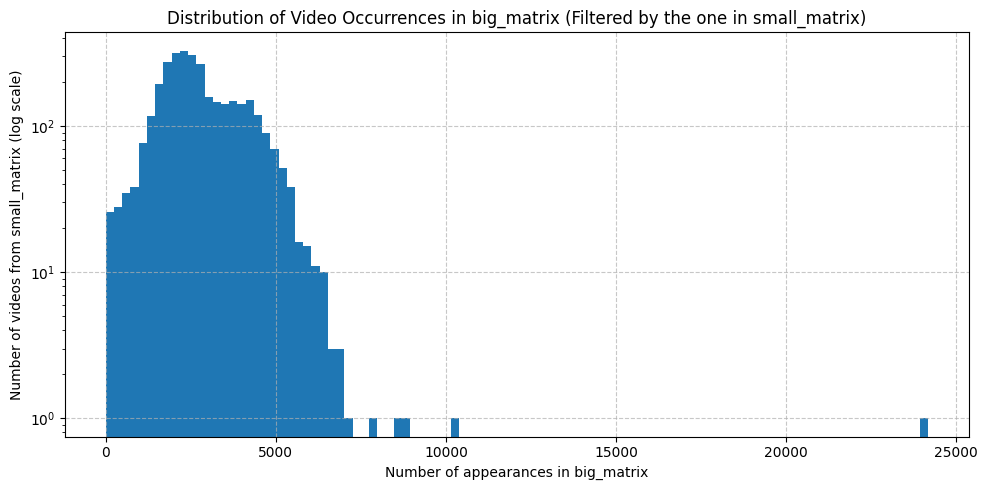

In [33]:
# Count how many times each video in A appears in B
video_ids_in_A = X_val['video_id'].unique()
video_counts_B = X_train['video_id'].value_counts()

# Get the counts for only those in A
counts_in_B = video_counts_B[video_ids_in_A]
counts_in_B = counts_in_B.fillna(0)  # In case some videos from A are missing in B

print(counts_in_B.describe())

# Plot a histogram of those counts
plt.figure(figsize=(10, 5))
plt.hist(counts_in_B, bins=100, log=True)
plt.title("Distribution of Video Occurrences in big_matrix (Filtered by the one in small_matrix)")
plt.xlabel("Number of appearances in big_matrix")
plt.ylabel("Number of videos from small_matrix (log scale)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We can see that the mean is about 2842 so it may be not enough to properly generalize.

---

# Preprocessing

To prepare the data:
- We **sort the interactions by timestamp** to preserve the order in which videos were watched.
- Then, we **group by `user_id`** to get each user's sequence of watched videos.
- Each user’s sequence is treated as a “sentence” of video IDs.

This results in a list of lists (sentences), where each list contains video IDs in the order they were watched by a user. These sentences are then fed into a Word2Vec model to learn meaningful video embeddings.

In [34]:
sentences = X_train.sort_values(by="timestamp").groupby("user_id")["video_id"].apply(list)
sentences

user_id
0       [3649, 9598, 5262, 1963, 8234, 8228, 6789, 681...
1       [5275, 1938, 3649, 183, 5262, 3586, 1965, 9594...
2       [9536, 5274, 5228, 9616, 6813, 5288, 6812, 200...
3       [5252, 5252, 1903, 8217, 9601, 8128, 8201, 680...
4       [178, 173, 8228, 6801, 1975, 5287, 3669, 3656,...
                              ...                        
7171    [5278, 1963, 172, 166, 3594, 5260, 3653, 5228,...
7172    [5278, 5257, 3613, 1963, 1829, 183, 6789, 175,...
7173    [172, 5275, 1963, 9616, 3654, 5273, 173, 171, ...
7174    [5231, 9597, 72, 6784, 8200, 1972, 5278, 168, ...
7175    [183, 1963, 172, 8234, 154, 3649, 6801, 6801, ...
Name: video_id, Length: 7176, dtype: object

---

# Training

We train a Word2Vec model on the user video sequences extracted earlier. The `min_count` parameter is set to 3, meaning that only videos appearing **at least 3 times across all sequences** are included in the vocabulary. This choice is supported by the earlier histogram analysis, which showed that all videos in the validation set occur at least 3 times in the training set.


In [35]:
model = Word2Vec(sentences=sentences, min_count=3)

---

# Evaluating

For each user in the validation set:

**Candidate Generation**:
- We compute the average embedding of the videos the user liked (`watch_ratio >= 2`) to form a preference query vector.
- Optionally, we subtract the average embedding of **disliked videos** (`watch_ratio < 0.8`) to better distinguish user intent. This helps refine recommendations by pushing the representation away from items the user was uninterested in.

**Recommendation Filtering**:
- We query the Word2Vec model for the most similar video embeddings.
- Videos the user has already seen during training are excluded to avoid recommending already-watched content.

**Evaluation Metrics**:
- We evaluate the top-K recommendations using precision, recall, MAP, NDCG, and hit rate, comparing them against the user's liked videos in the validation set.

Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:11<00:00,  8.96it/s]



Metrics @ K=5:
  Precision@K: 0.1200
  Recall@K: 0.0060
  MAP@K: 0.0863
  NDCG@K: 0.1363
  HitRate@K: 0.3800

Metrics @ K=10:
  Precision@K: 0.0970
  Recall@K: 0.0099
  MAP@K: 0.0540
  NDCG@K: 0.1148
  HitRate@K: 0.5100

Metrics @ K=20:
  Precision@K: 0.0850
  Recall@K: 0.0154
  MAP@K: 0.0370
  NDCG@K: 0.1010
  HitRate@K: 0.6000

Metrics @ K=50:
  Precision@K: 0.0616
  Recall@K: 0.0275
  MAP@K: 0.0216
  NDCG@K: 0.0797
  HitRate@K: 0.6800

Metrics @ K=100:
  Precision@K: 0.0532
  Recall@K: 0.0465
  MAP@K: 0.0165
  NDCG@K: 0.0764
  HitRate@K: 0.7500


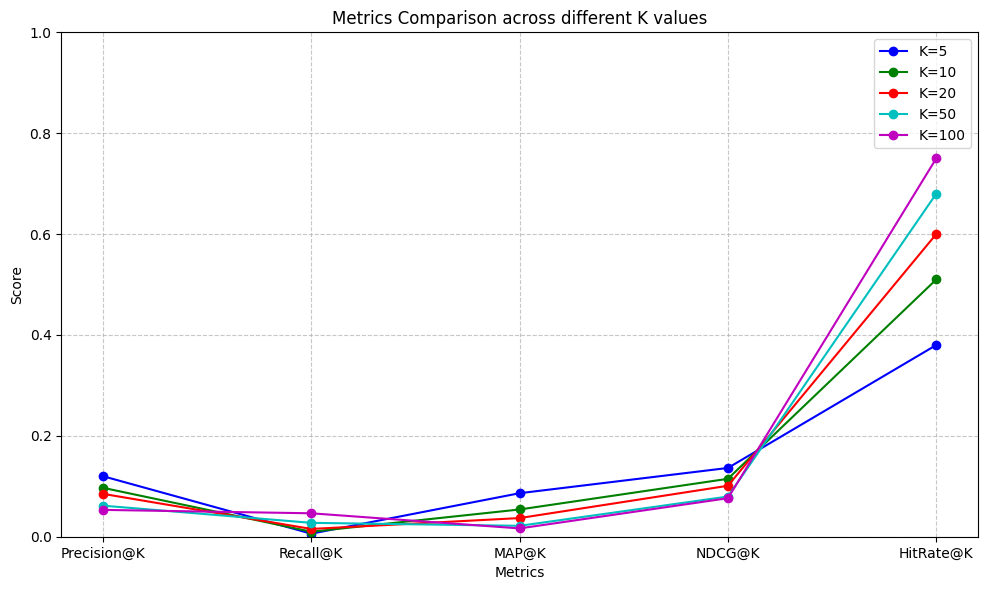

In [43]:
# ------------------------
# Initialize metrics containers for metrics
# ------------------------
K=100
reco = RecoMetrics()

def recommend_simple(user_id, dislike=True):
    liked_items = X_train[(X_train['user_id'] == user_id) & (X_train['watch_ratio'] >= 2)]['video_id'].values
    seen_train = set(X_train[X_train['user_id'] == user_id]['video_id'].values)

    # If no liked items, skip this user
    if len(liked_items) == 0:
        return []

    query = np.mean([model.wv[item] for item in liked_items if item in model.wv], axis=0)

    if dislike:
        unliked_items = X_train[(X_train['user_id'] == user_id) & (X_train['watch_ratio'] < 0.8)]['video_id'].values
        if len(unliked_items) > 0:
            query -= np.mean([model.wv[item] for item in unliked_items if item in model.wv], axis=0)

    recommended_items = model.wv.similar_by_vector(query, topn=K + len(seen_train))

    df = pd.DataFrame(recommended_items, columns=["prediction_id", "score"])
    df = df[~df["prediction_id"].isin(seen_train)]
    return df["prediction_id"][:K].tolist()

for user_id in tqdm(X_val['user_id'].unique()[:100], desc="Evaluating"):
    # Filter rows based on user_id and liked == 1 in one step
    liked_items = X_val[(X_val['user_id'] == user_id) & (X_val['watch_ratio'] >= 2)]['video_id'].values

    # If no liked items, skip this user
    if len(liked_items) == 0:
        continue

    recommended_items = recommend_simple(user_id)

    if len(recommended_items) == 0:
        continue

    reco.add_evaluation(liked_items, recommended_items)

reco.plot()

# Analysis of Performance

**Observations:**
- **Precision@K and MAP@K** decrease as K increases, which is expected because adding more items dilutes the quality of top-ranked recommendations.
- **Recall@K and HitRate@K** increase with K, reflecting broader coverage of liked items, but precision suffers.
- **NDCG@K** follows a similar trend to MAP@K, reinforcing that relevant items are generally ranked lower as K grows.

---

### Reflections and Experimental Insights

#### 1. Assumption About Temporal Similarity Might Be Flawed
Our approach assumes that **videos watched sequentially by a user are semantically related**. However, in real usage (especially in short-video platforms), users are often served algorithmic recommendations that can **jump between topics quickly**. This breaks the assumption that temporal proximity equates to content similarity.

We attempted to improve this by grouping videos using their **high-level features from** `item_categories.csv`, but performance dropped further. This suggests that, despite noise, **timestamp order still encodes more meaningful user behavior** than static item attributes.

Another idea was instead of having a single "sentence" per user to split by session. When the time between two consecutives watch is greater than X, we consider it another session and so another sentences. By lack of time we didn't try this option.

#### 2. Evaluation Set Item Coverage
Has seen in the previous histogram, many videos appearing in the validation set are **rare or absent in the training set**, making it harder for models trained only on common co-occurrences to generalize.

#### 3. Limitation of Global Aggregation
Initially, we built user embeddings by averaging all liked videos (and subtracting disliked ones). However, this global aggregation may obscure distinct user preferences if a user enjoys **diverse types of content**.

To address this, we tried a **cluster-aware recommendation strategy**:
- We clustered the Word2Vec item embeddings into 31 groups (aligned with the number of distinct categories in `item_categories.csv`).
- For each user, liked and disliked videos were segmented by cluster.
- For each cluster, we created a localized preference vector: **mean of liked - mean of disliked**.
- The number of recommendations drawn from each cluster was proportional to how many liked items the user had in that cluster (e.g., if 90% of likes were in cluster X, 90% of recommendations came from it).

While this approach is **conceptually sound** and preserves user interest diversity, the **actual results were disappointing**, possibly due to:
- Poor cluster separation in the embedding space.
- Data sparsity within clusters.
- Reduced global coherence in the final ranked list.

---

### Conclusion

The Item2Vec-based approach provides reasonable performance as a content-free baseline, especially in terms of hit rate. However, its assumptions — particularly around temporal similarity and uniform user intent — limit its upper-bound performance. More refined models may need to add more metadata.